# Model Evaluator Example
This notebook shows how to get a performance report for the different models, and how to compare them.

### Imports

In [1]:
from models.regex import RegexModel
from models.tf_idf import TFIDFClassifier
from models.embedder_with_classification_head import EmbedderClassifier
from models.fine_tuned_BERT_models.classifier import BERTBasedModel
from data_loader import AnnotationDataLoader
from model_evaluation import ModelEvalWrapper, ModelEvaluator, ReportsComparison

c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Test Data

In [2]:
dataloader = AnnotationDataLoader()
test_set = dataloader.get_last_test_set_no_overlap()

### Generating Model Reports

#### RegEx model

In [3]:
regex = RegexModel()
regex_wrapper = ModelEvalWrapper(regex, "RegEx", "Baseline RegEx classifier")
regex_evaluator = ModelEvaluator(regex_wrapper, test_set)
regex_report = regex_evaluator.generate_report()

#### TF-IDF model

In [4]:
tfidf = TFIDFClassifier.load_from_file("models/tf_idf/ComplementNaiveBayes_TF-IDF.pkl")
tfidf_wrapper = ModelEvalWrapper(tfidf, "TF-IDF", "TF-IDF classifier")
tfidf_evaluator = ModelEvaluator(tfidf_wrapper, test_set)
tfidf_report = tfidf_evaluator.generate_report()

c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ComplementNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using versi

#### Pre-trained BERT encoder with classification head

In [6]:
pretrained = EmbedderClassifier.load_model()
pretrained_wrapper = ModelEvalWrapper(pretrained, "Pre-trained encoder", "Pre-trained BERT-based encoder with classification head")
pretrained_evaluator = ModelEvaluator(pretrained_wrapper, test_set)
pretrained_report = pretrained_evaluator.generate_report()

c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\milap\Anaconda\envs\IBP_env\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


#### Fine-tuned BERT encoder and classfication layer

In [7]:
model_link = "Mila-MP/inPhormer-LLM-classifier"
subfolder = "final_llm"

In [8]:
finetuned = BERTBasedModel(model_dir=model_link, subfolder=subfolder)
finetuned_wrapper = ModelEvalWrapper(finetuned, "Fine-tuned encoder", "Fine-tuned BERT-based encoder and classification layer")
finetuned_evaluator = ModelEvaluator(finetuned_wrapper, test_set)
finetuned_report = finetuned_evaluator.generate_report()

### Display Reports


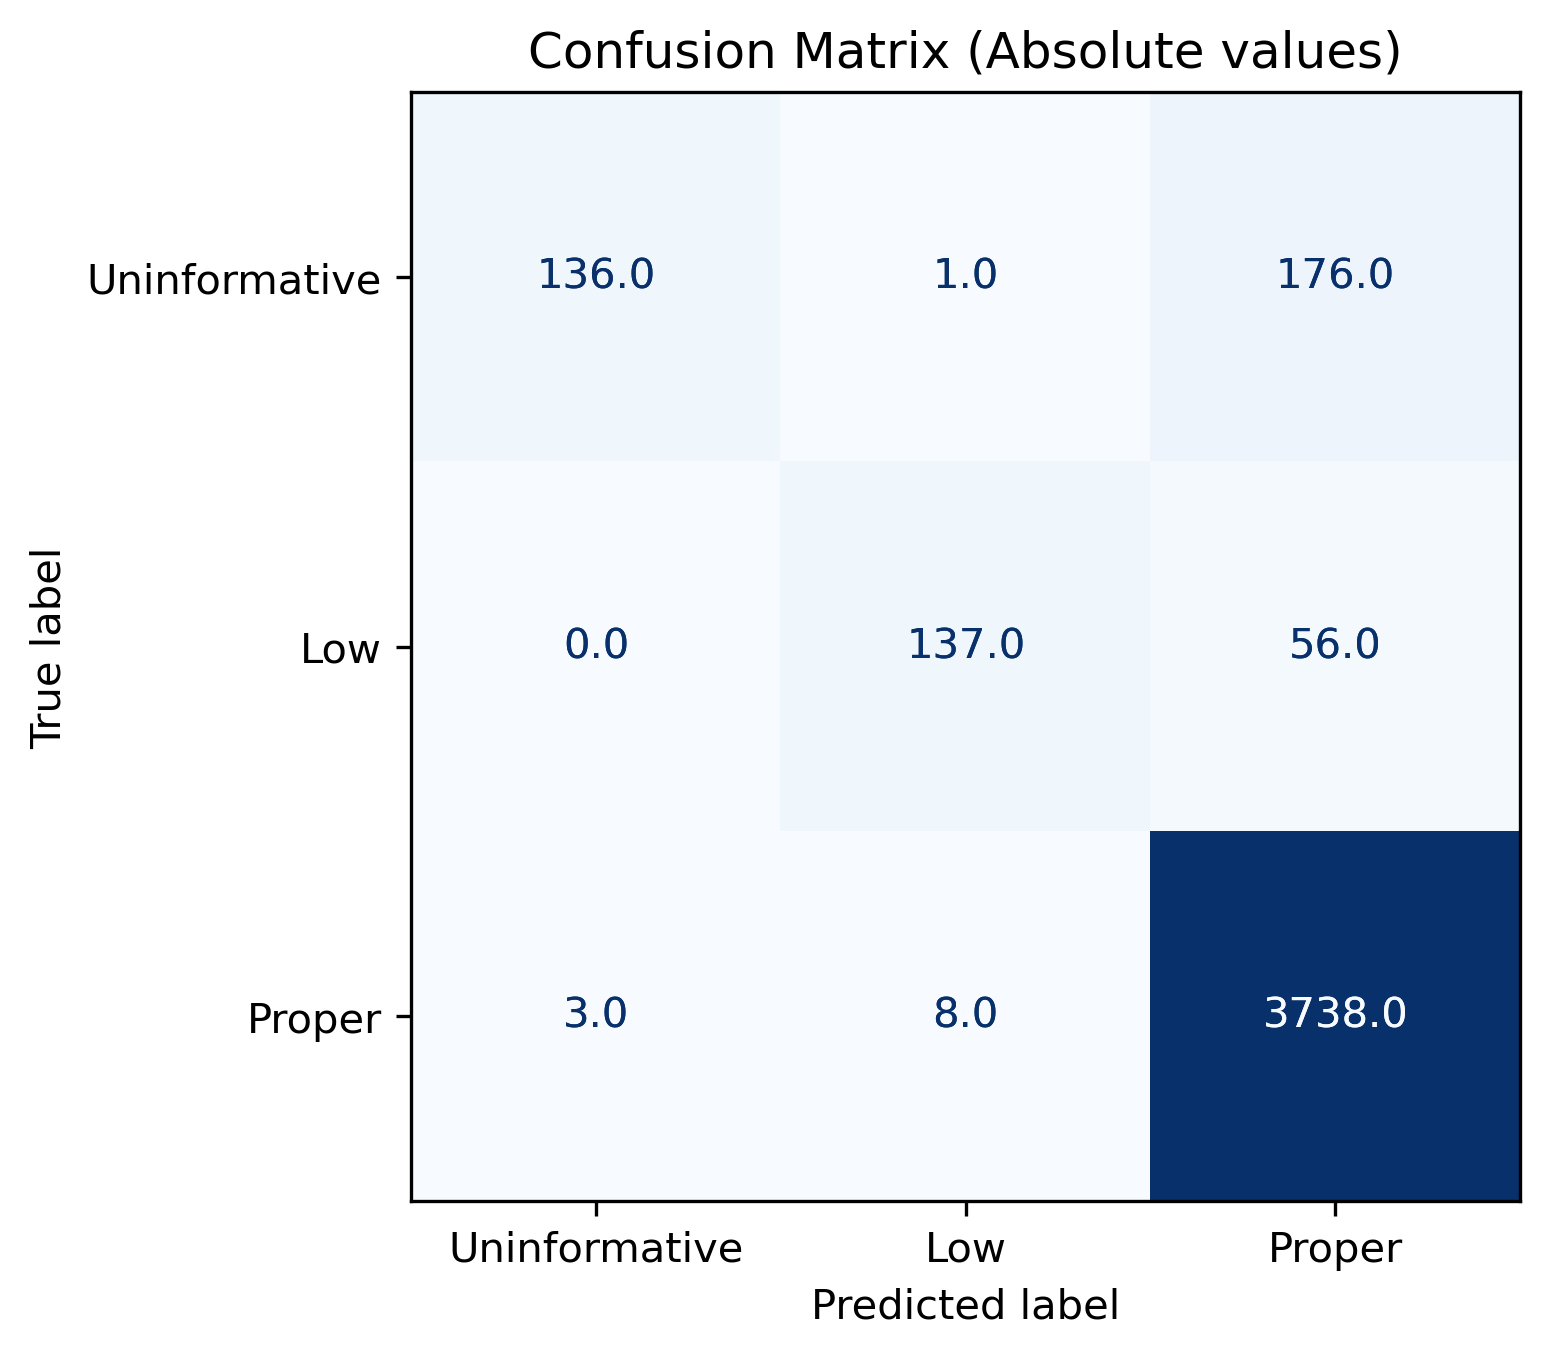
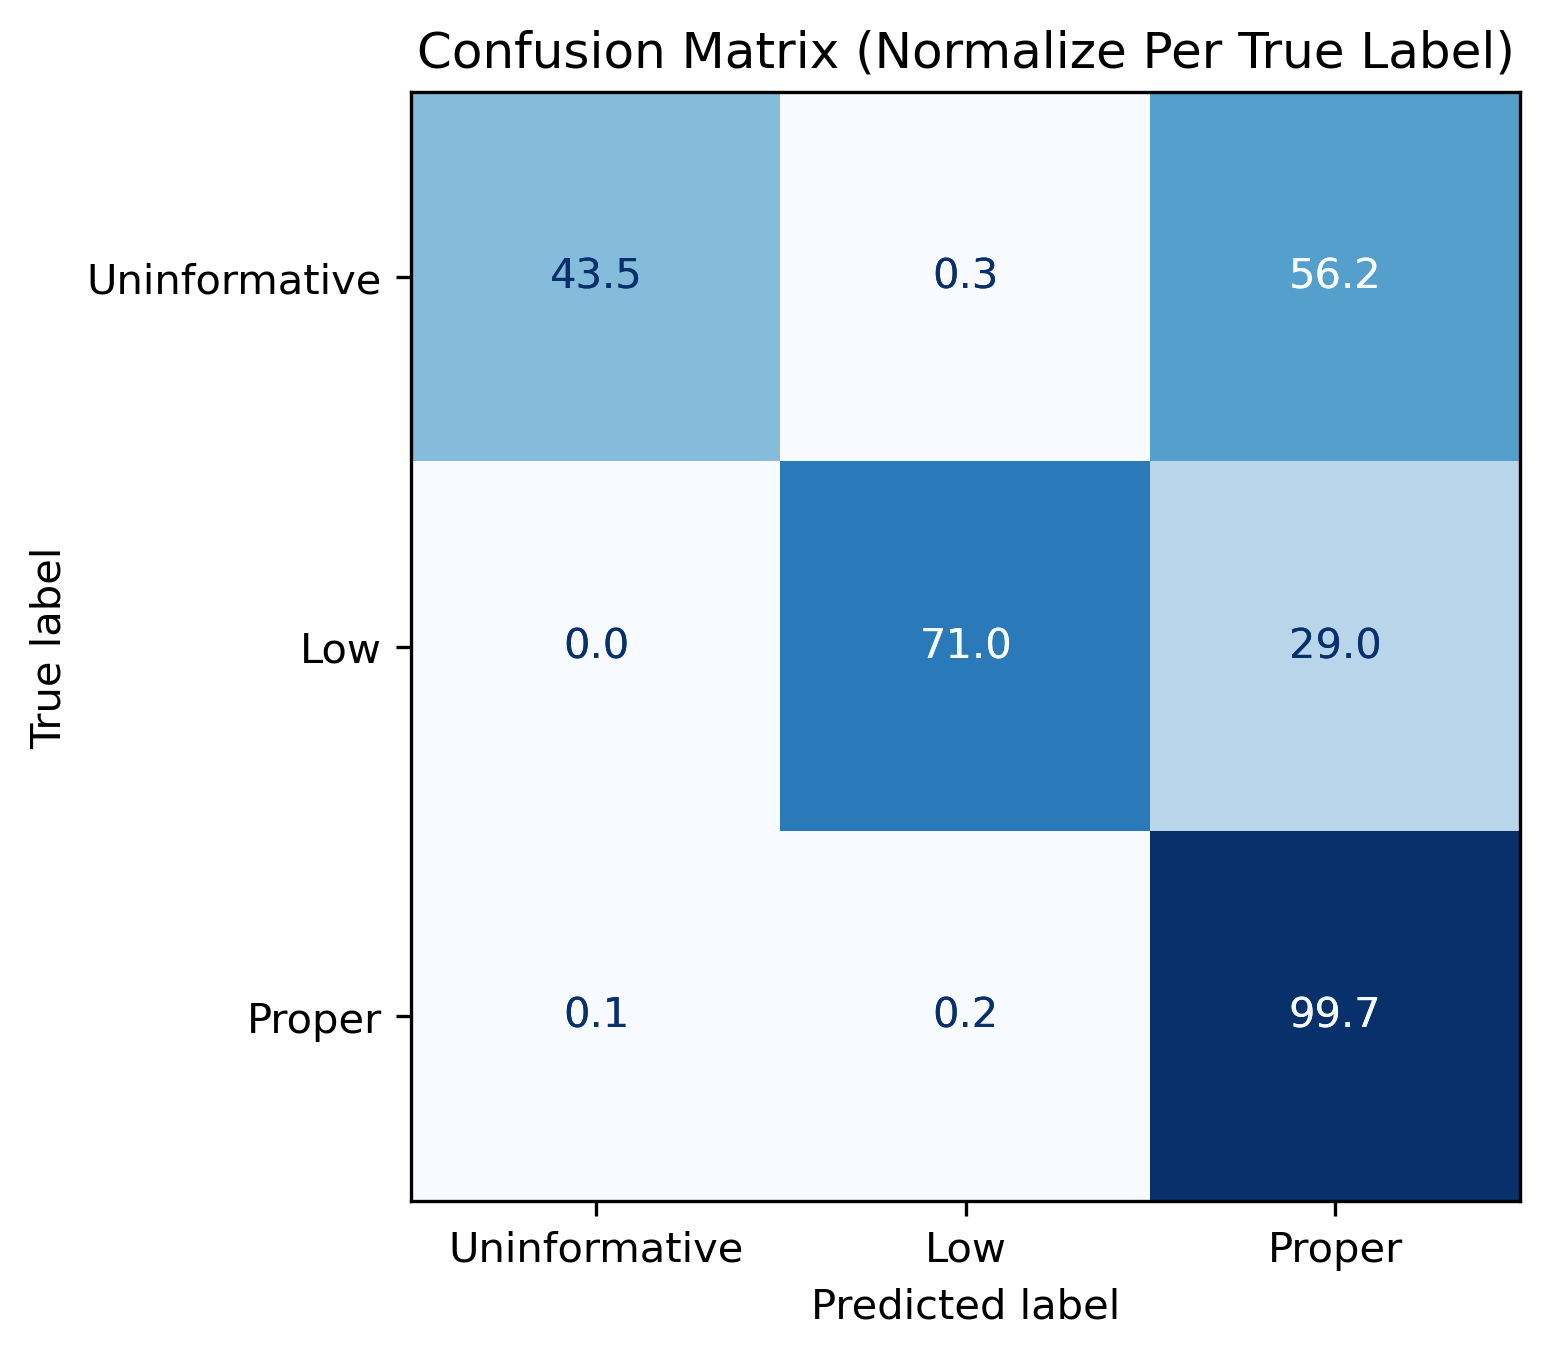

In [9]:
regex_report.show_report()


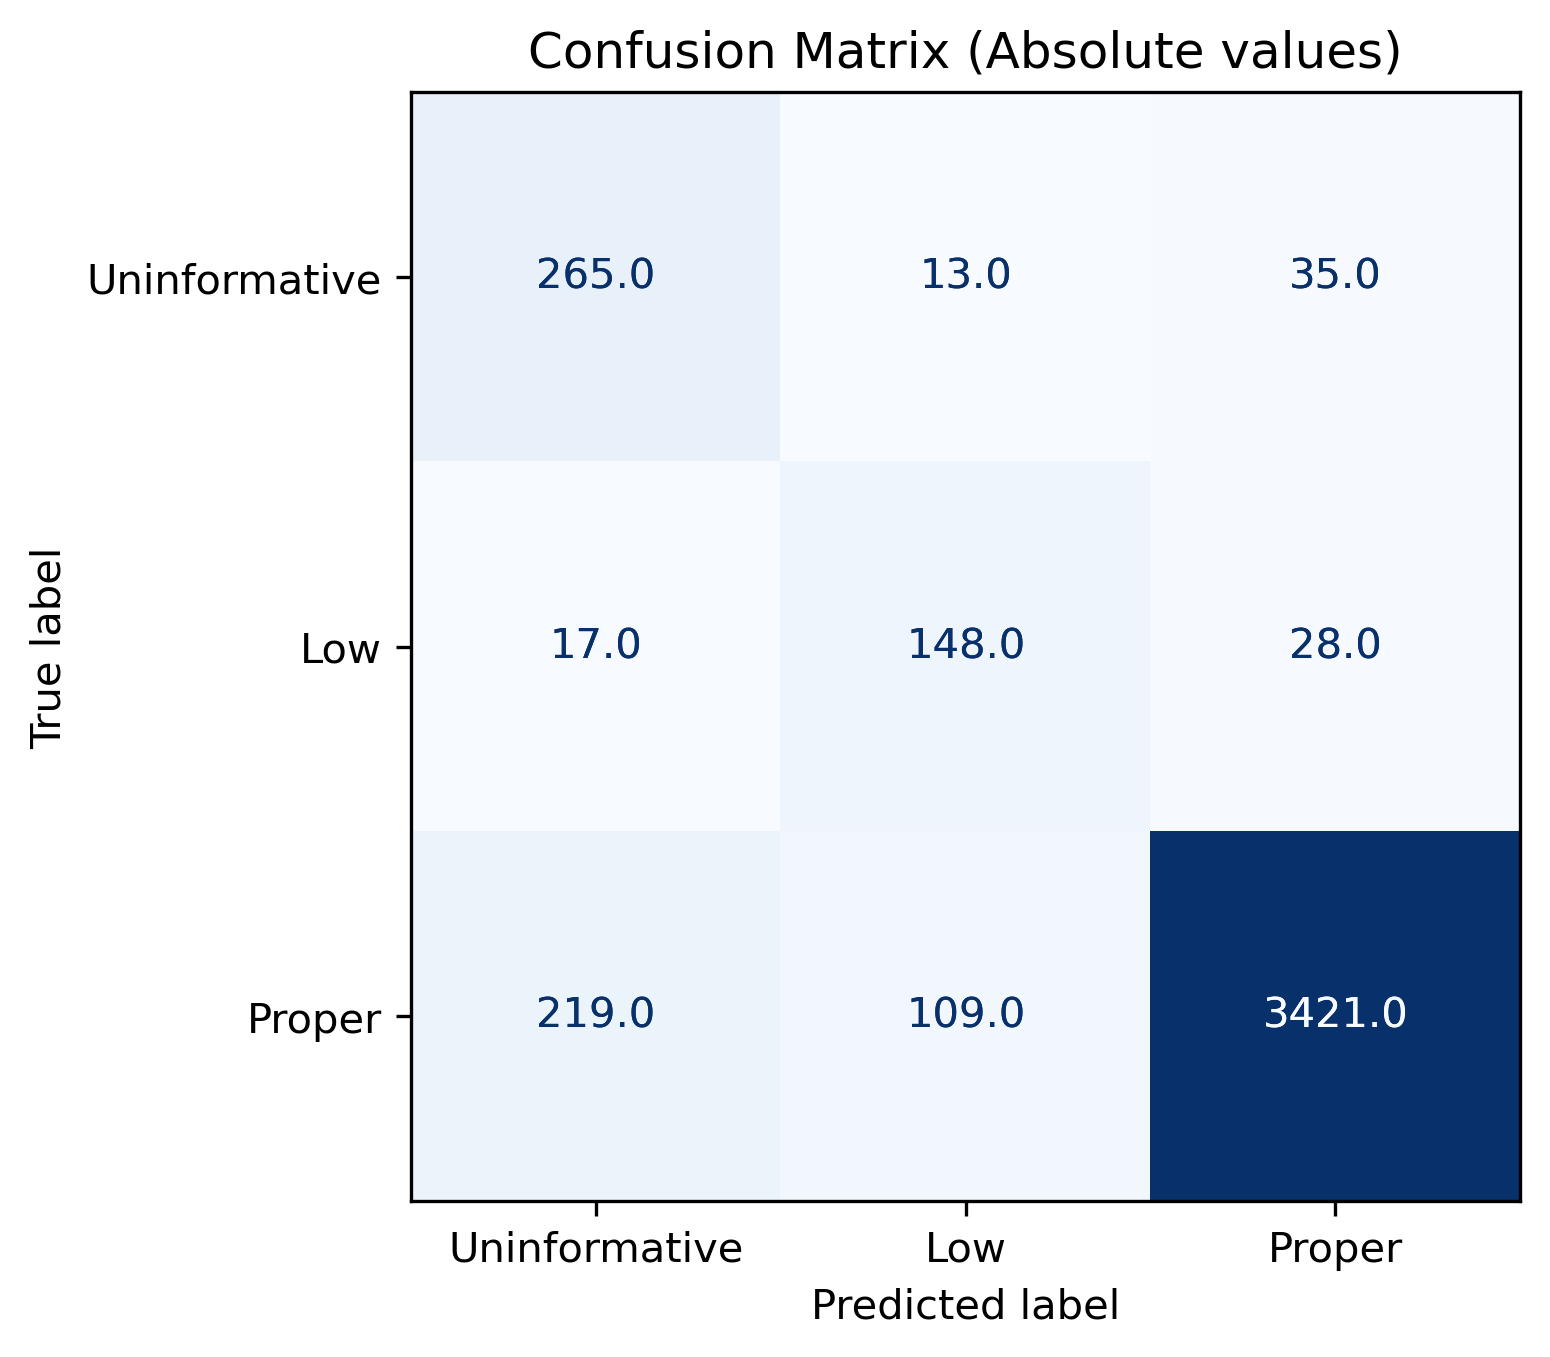
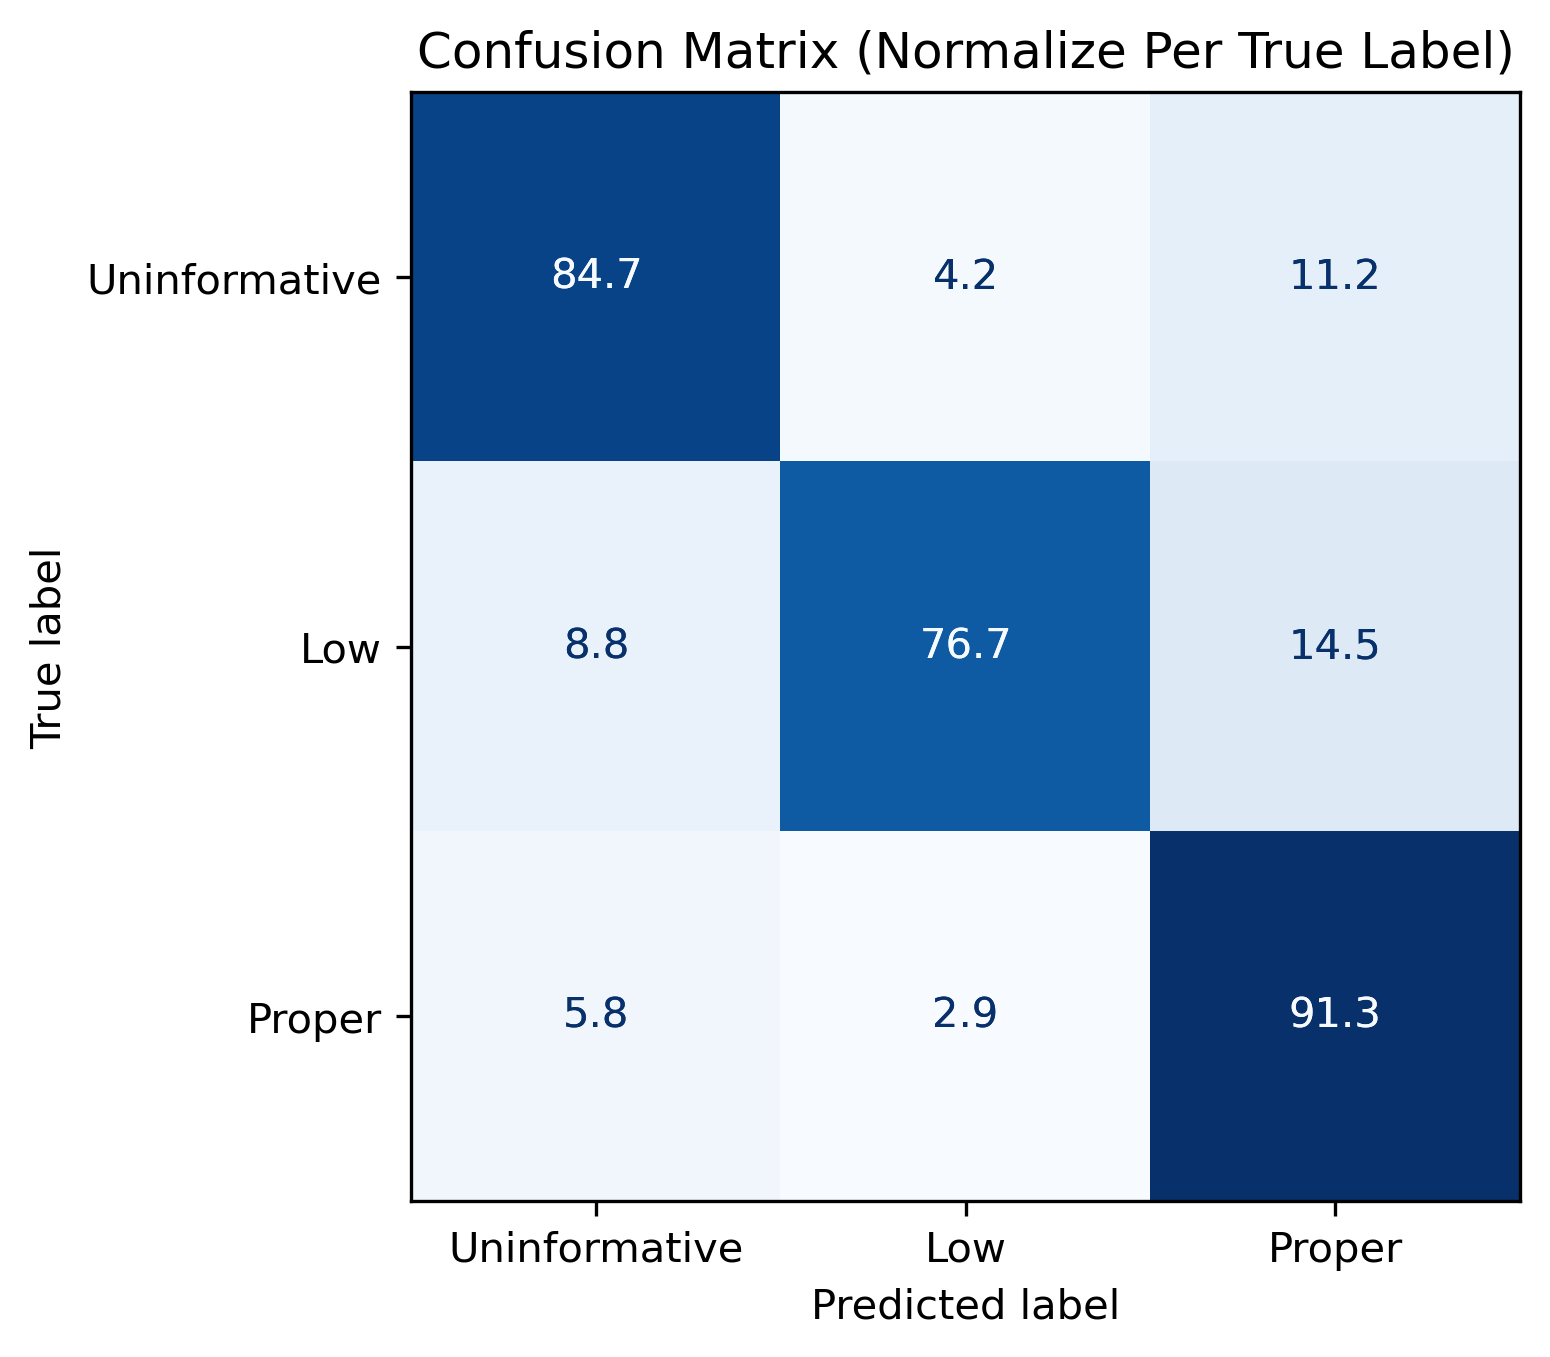

In [10]:
tfidf_report.show_report()


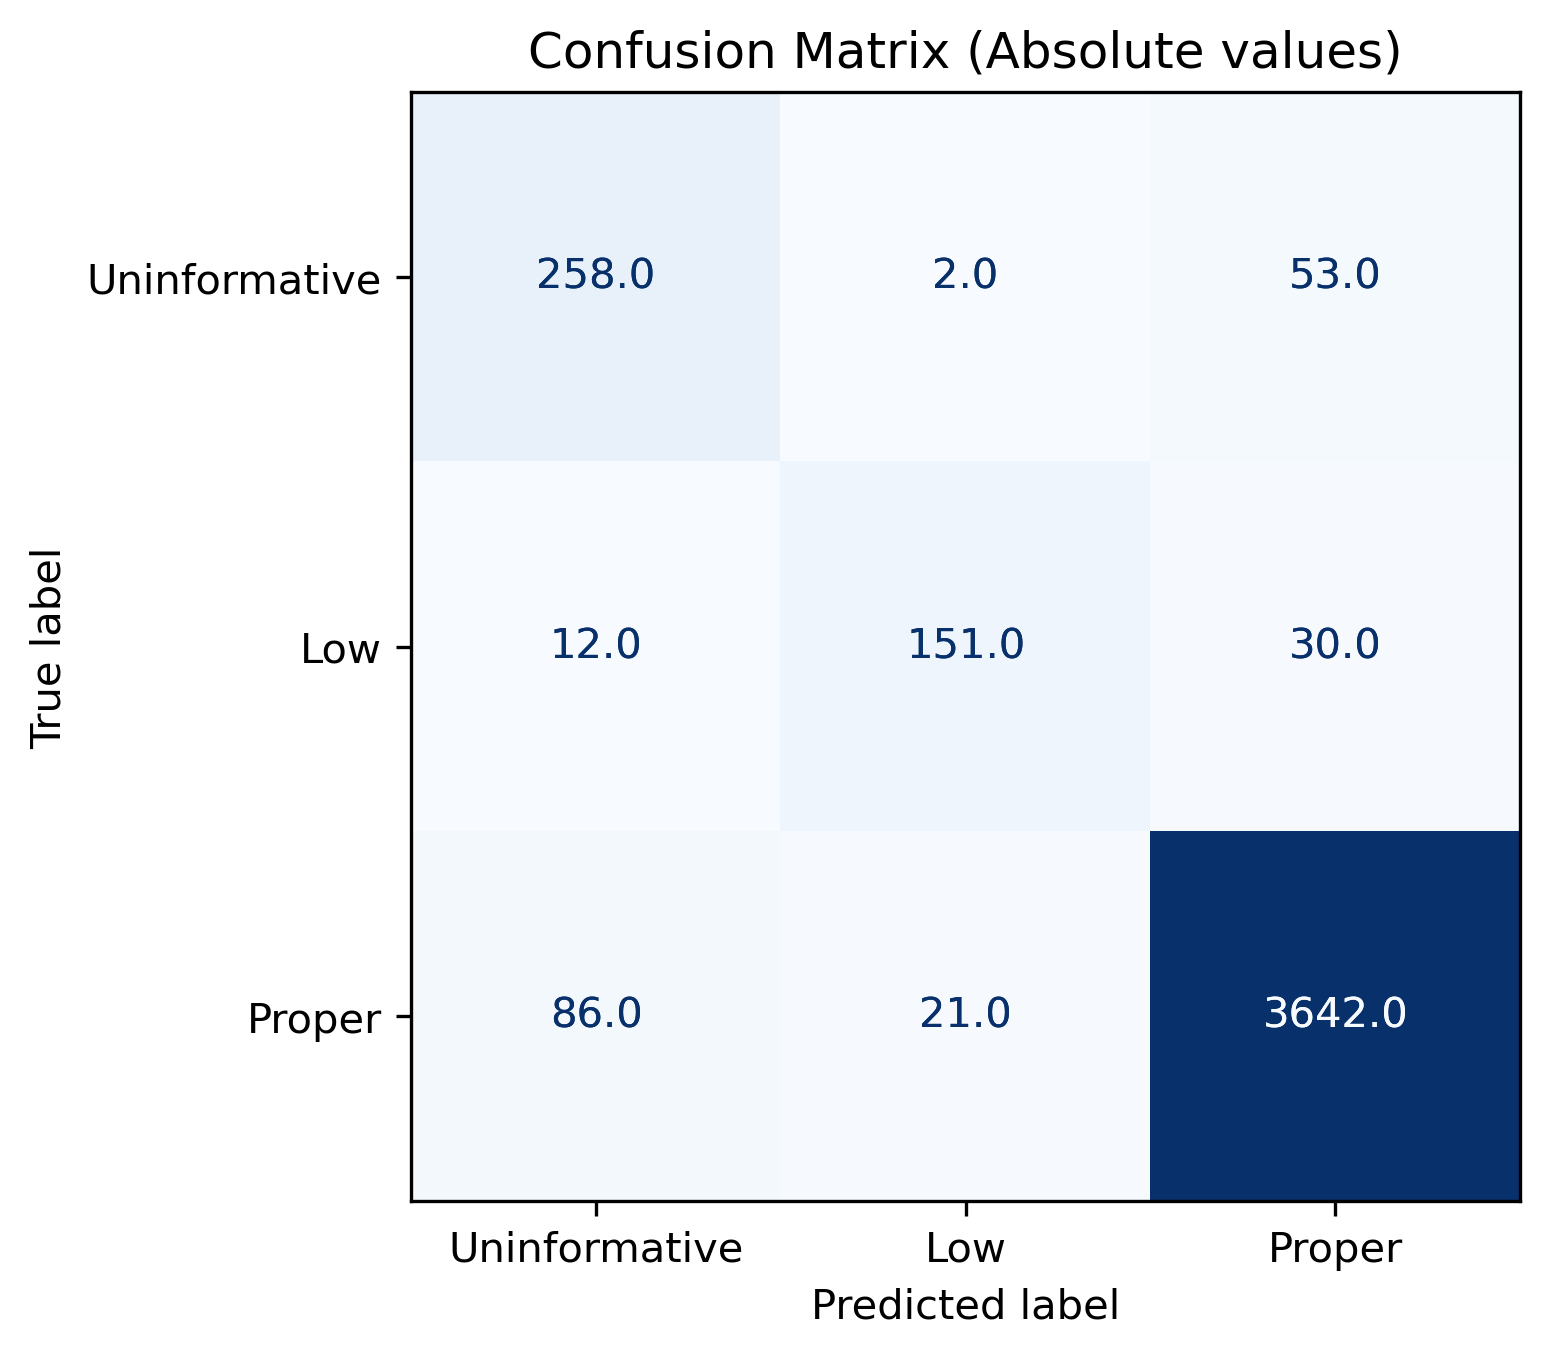
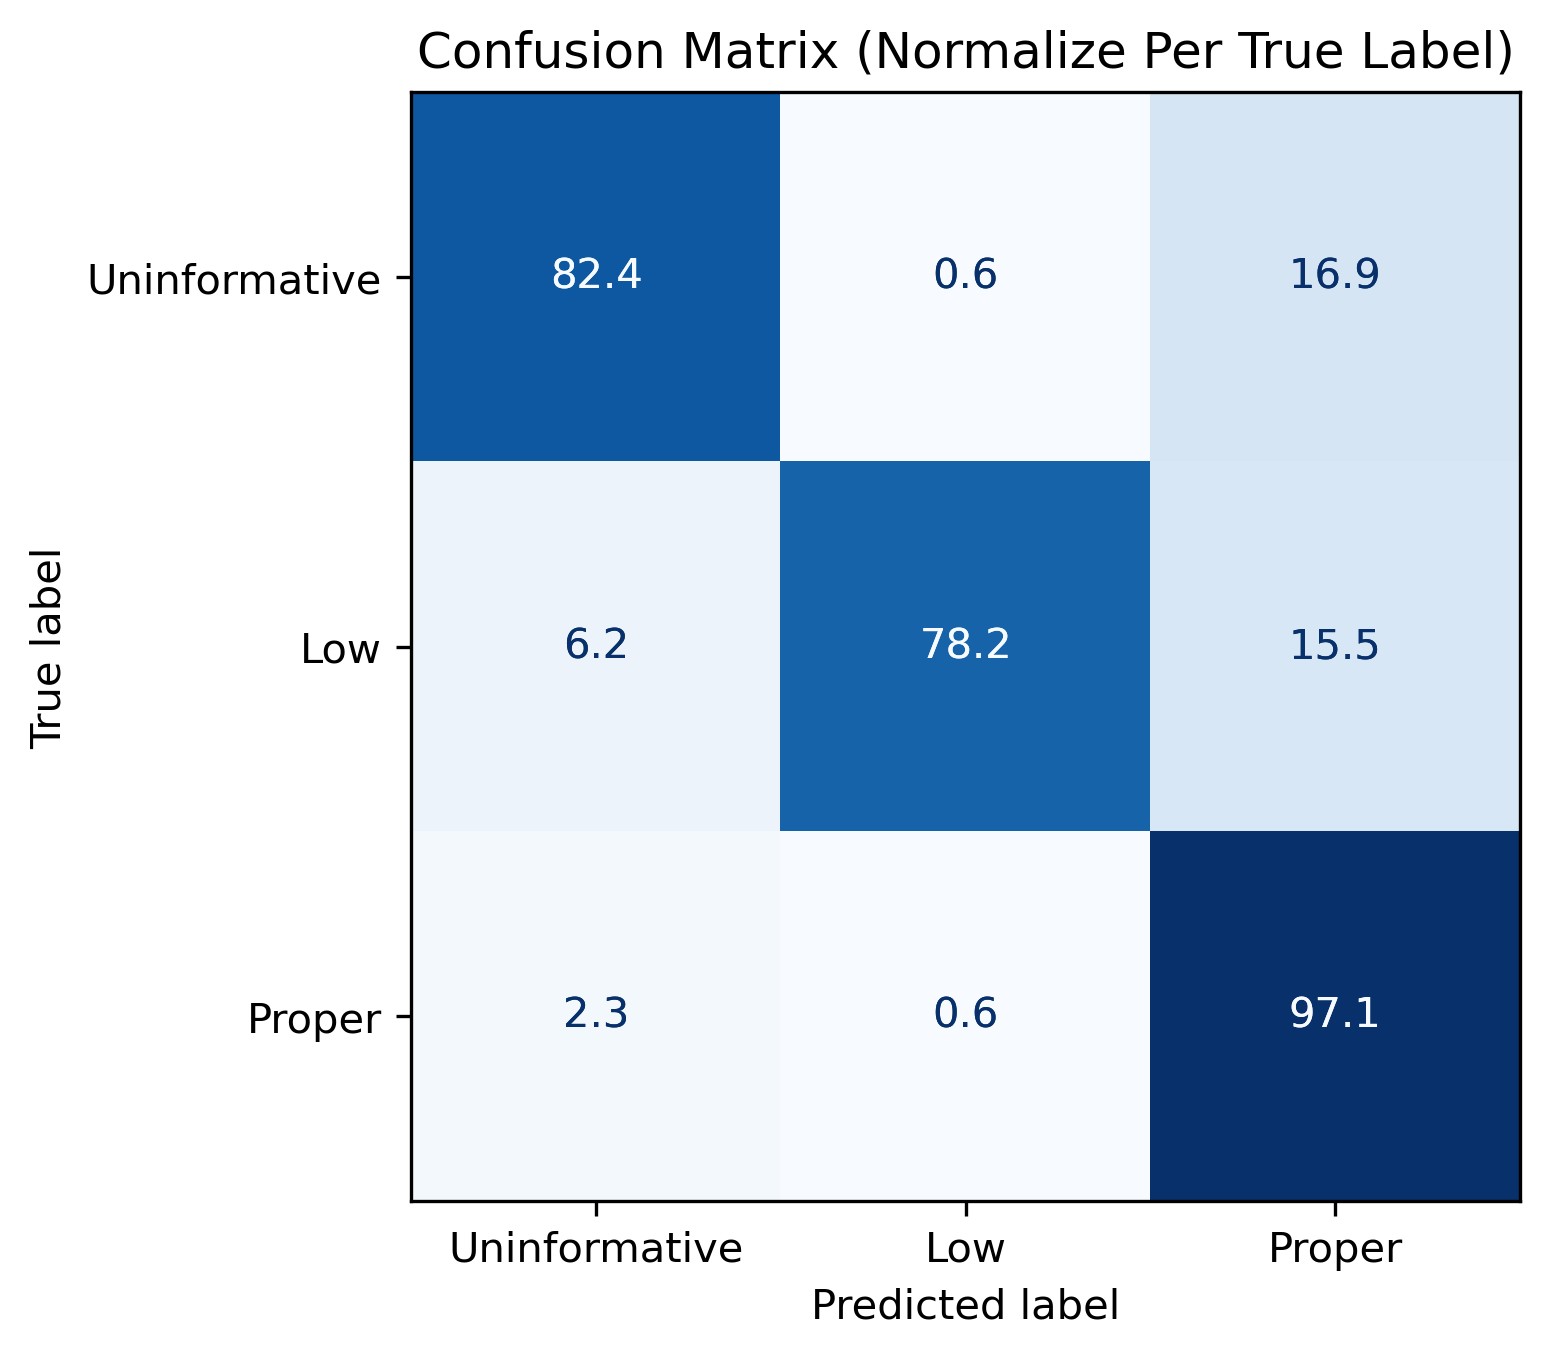

In [11]:
pretrained_report.show_report()


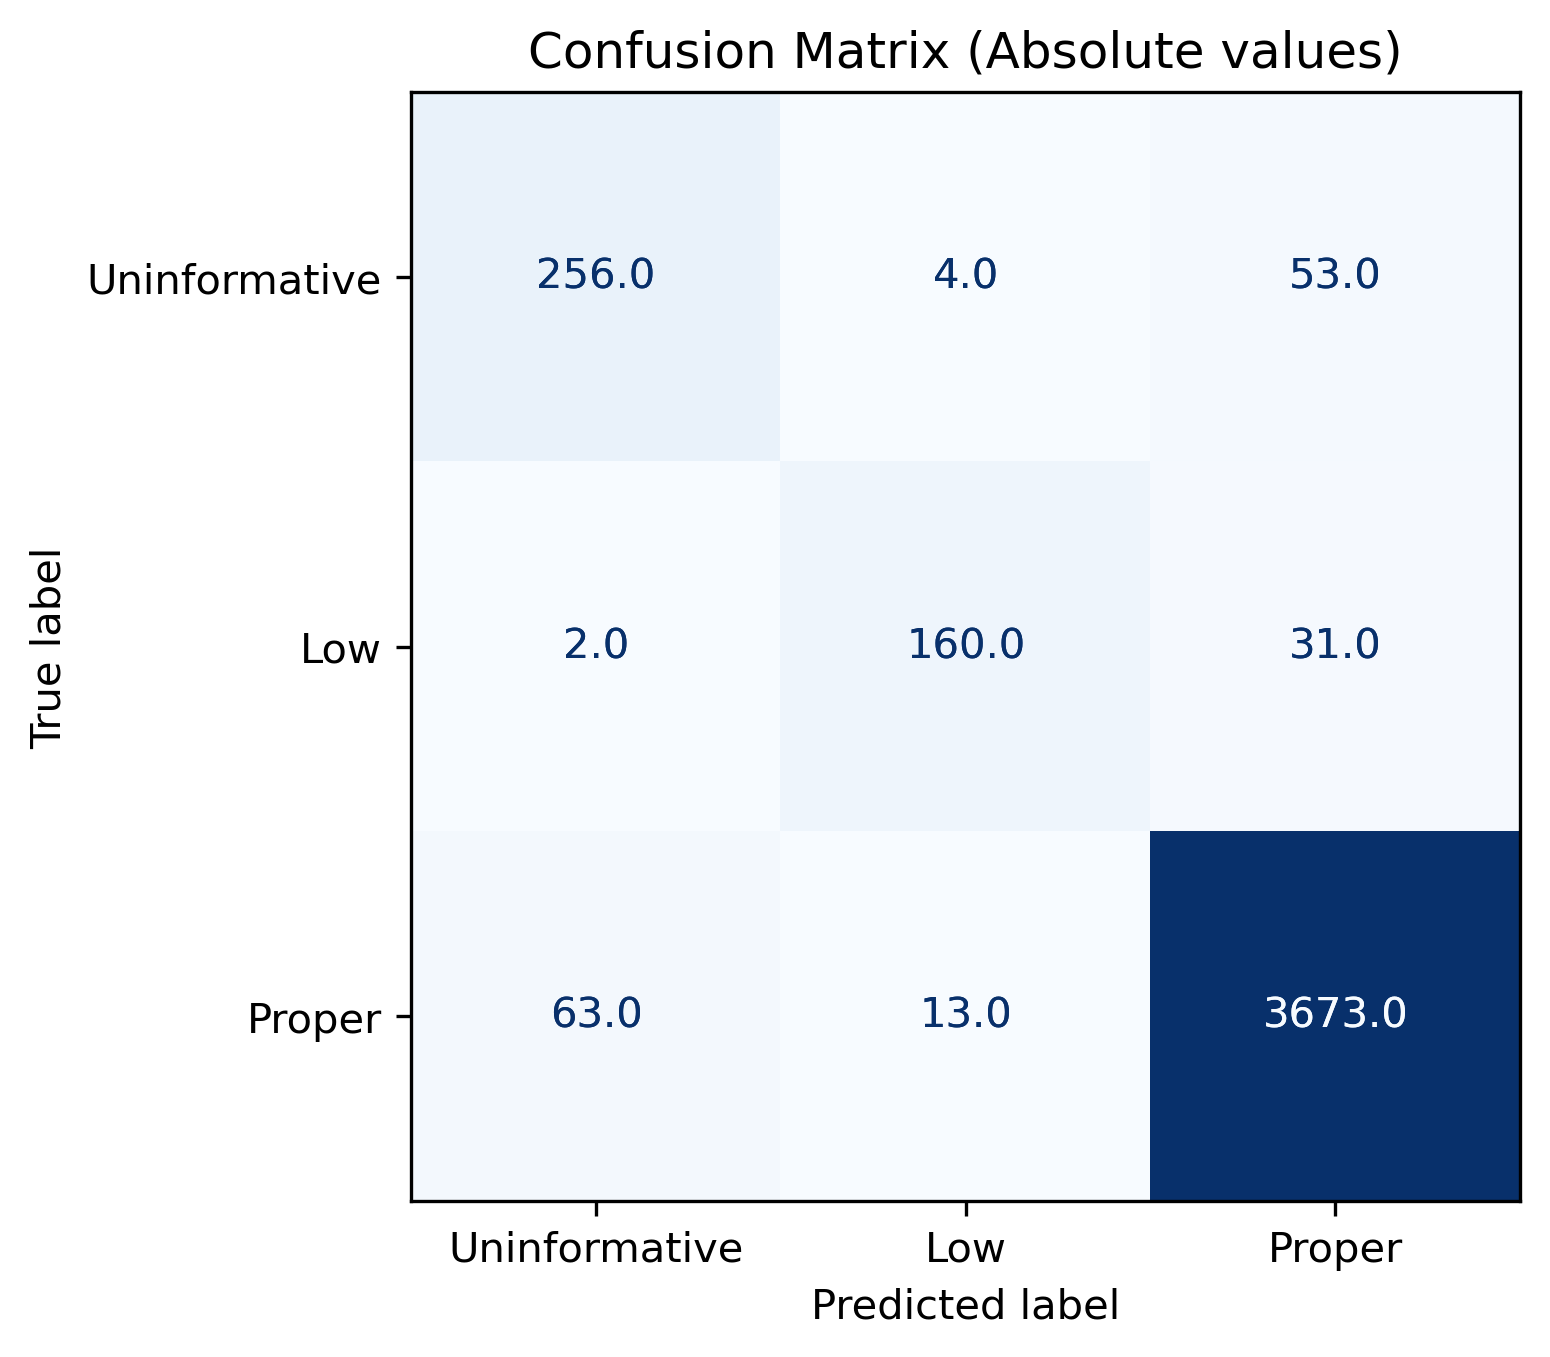
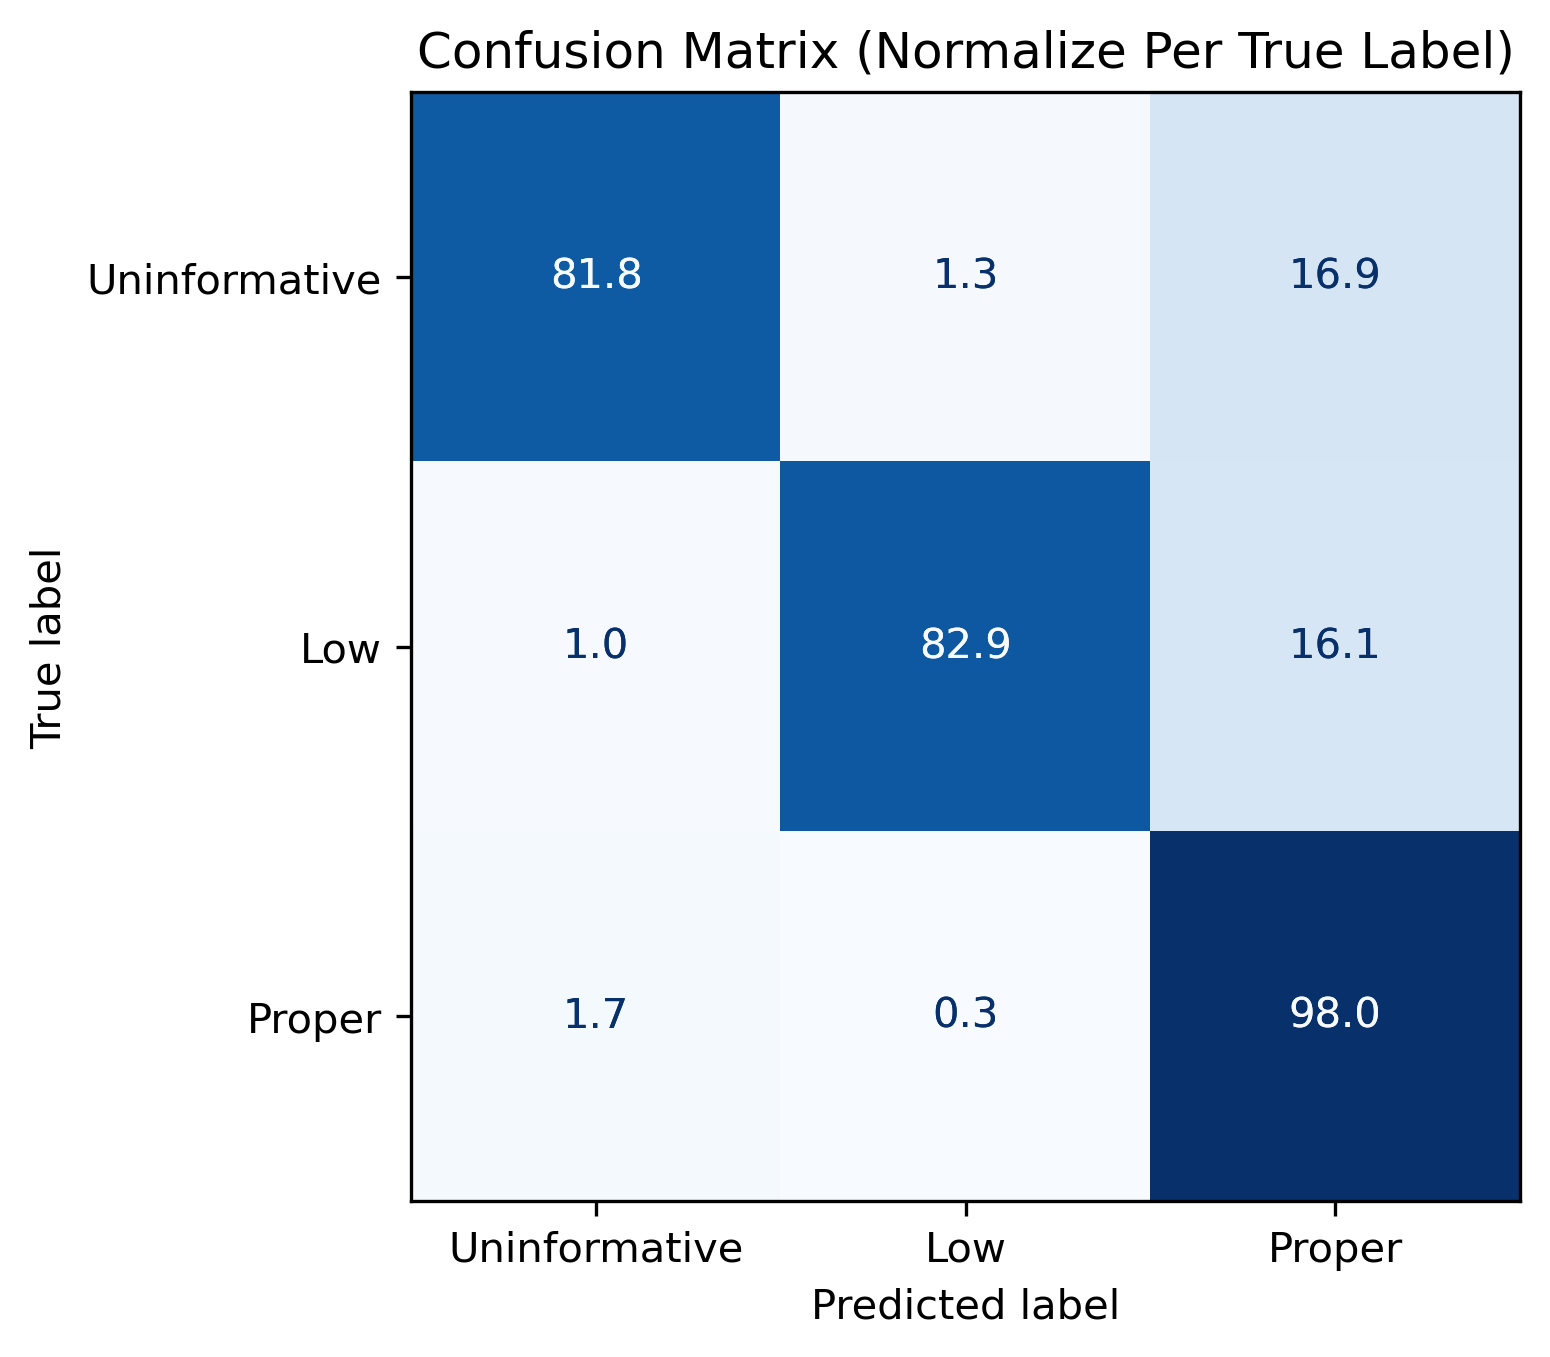

In [12]:
finetuned_report.show_report()

In [16]:
finetuned_report.show_misclassified_samples()

,protein_annotation,true_label,predicted_label
5,TniQ protein,0,2
11,Protein of hypothetical function SprT,0,2
14,SbsB protein,0,2
49,Sll1037 protein,2,0
144,Ubiquitous surface protein A2,1,2
...,...,...,...
4167,WD40 repeat,1,2
4170,AAEL005605-PA,2,0
4179,Mu-like prophage FluMu protein GP27,0,2
4203,TfmS,0,2


### Compare Reports

In [13]:
reports = [regex_report, tfidf_report, pretrained_report, finetuned_report]
report_compare = ReportsComparison(reports)

In [14]:
report_compare.show_comparison_table() 

In [15]:
report_compare.show_comparison_plot()

In [17]:
report_compare.get_comparison_df()

,Model,Model_info,Accuracy,Average Time Per Prediction,Macro Average (precision),Macro Average (recall),Macro Average (f1-score),Macro Average (support),Weighted Average (precision),Weighted Average (recall),...,f1-score - Uninformative,support - Uninformative,precision - Low,recall - Low,f1-score - Low,support - Low,precision - Proper,recall - Proper,f1-score - Proper,support - Proper
0,RegEx,Baseline RegEx classifier,0.942656,0.000046,0.952778,0.713805,0.792850,4255.0,0.944127,0.942656,...,0.601770,313.0,0.938356,0.709845,0.808260,193.0,0.941562,0.997066,0.968519,3749.0
1,TF-IDF,TF-IDF classifier,0.901058,0.004512,0.686336,0.841998,0.745452,4255.0,0.928921,0.901058,...,0.651106,313.0,0.548148,0.766839,0.639309,193.0,0.981917,0.912510,0.945942,3749.0
2,Pre-trained encoder,Pre-trained BERT-based encoder with classifica...,0.952056,0.002319,0.856751,0.859375,0.856256,4255.0,0.954122,0.952056,...,0.771300,313.0,0.867816,0.782383,0.822888,193.0,0.977718,0.971459,0.974579,3749.0
3,Fine-tuned encoder,Fine-tuned BERT-based encoder and classificati...,0.960987,0.004662,0.893035,0.875545,0.883707,4255.0,0.961049,0.960987,...,0.807571,313.0,0.903955,0.829016,0.864865,193.0,0.977642,0.979728,0.978684,3749.0
